In [8]:
import os
import numpy as np
import proplot as pplt
import pandas as pd
from dask.sizeof import sizeof
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
from glob import glob

arr = np.load('your_directory/loads/subregion_mask.npz', allow_pickle=True)['id_to_subregion']
label_list = arr[:, 1].tolist()
label_list = [s.replace('NorthernGrid', 'NG').replace('WestConnect', 'WC') for s in label_list]
label_list = [s.replace('Central', 'C').replace('North', 'N').replace('South', 'S').replace('East', 'E').replace('West', 'W') for s in label_list]

In [9]:
def normalize_by_rcp45cooler_min(data,data30):
    for sub_id, sub_data in data.items():
        if 'rcp45cooler' in sub_data:
            base_min = np.nanmin(sub_data['rcp45cooler'])  
            for scenario in sub_data:
                sub_data[scenario] = sub_data[scenario] - base_min
    return data
colors_rcp45 = [
    (126/255, 182/255, 226/255),  
    (106/255, 162/255, 206/255),  
    (86/255, 142/255, 186/255),   
]
colors_rcp85 = [
    (245/255, 187/255, 188/255),  
    (235/255, 167/255, 168/255),  
    (225/255, 147/255, 148/255),  
]

In [ ]:
fig, axs = pplt.subplots(nrows=3, ncols=6, figsize=(4.2, 3.5),  wspace=0, hspace=2.2,sharey=True, sharex=True,spany=False,dpi=300)
fig.patch.set_facecolor('white')
k = 0
data30 = np.load('your_directory/loadgenvio_2030.npz', allow_pickle=True)['violin'].item()
data40 = np.load('your_directory/loadgenvio_2040.npz', allow_pickle=True)['violin'].item()
data50 = np.load('your_directory/loadgenvio_2050.npz', allow_pickle=True)['violin'].item()
data30 = normalize_by_rcp45cooler_min(data30,data30)
data40 = normalize_by_rcp45cooler_min(data40,data30)
data50 = normalize_by_rcp45cooler_min(data50,data30)
label_num = [str(i + 1) for i in range(18)]
for i, sub_id in enumerate(label_num):
    ax = axs[k+i]
    data_rcp45 = {}
    data_rcp85 = {}
    growth_2030_2040 = []
    growth_2040_2050 = []
    for year, dataset in zip([2030, 2040, 2050], [data30, data40, data50]):
        sub_data = dataset.get(sub_id, {})
        if 'rcp45cooler' in sub_data:
            data_rcp45[year] = sub_data['rcp45cooler']
        if 'rcp85hotter' in sub_data:
            data_rcp85[year] = sub_data['rcp85hotter']
    if data_rcp45 and data_rcp85:

        df_rcp45 = pd.DataFrame(dict(sorted(data_rcp45.items())))
        df_rcp85 = pd.DataFrame(dict(sorted(data_rcp85.items())))
        xlabels = [str(year) for year in sorted(data_rcp45.keys())]
        x_pos_45 = np.arange(len(xlabels))
        x_pos_85 = x_pos_45 + 0.5

        lower_rcp45 = np.percentile(df_rcp45, 10, axis=0)
        upper_rcp45 = np.percentile(df_rcp45, 90, axis=0)
        mean_rcp45 = (lower_rcp45 + upper_rcp45) / 2
        err_low_rcp45 = mean_rcp45 - lower_rcp45
        err_high_rcp45 = upper_rcp45 - mean_rcp45

        lower_rcp85 = np.percentile(df_rcp85, 10, axis=0)
        upper_rcp85 = np.percentile(df_rcp85, 90, axis=0)
        mean_rcp85 = (lower_rcp85 + upper_rcp85) / 2
        err_low_rcp85 = mean_rcp85 - lower_rcp85
        err_high_rcp85 = upper_rcp85 - mean_rcp85

        for j in range(3):
            ax.errorbar(x_pos_45[j], mean_rcp45[j], yerr=np.array([[err_low_rcp45[j]], [err_high_rcp45[j]]]), elinewidth=1, capthick=1,
                        fmt='o', ms=4, markerfacecolor=colors_rcp45[2], markeredgecolor='none', ecolor='green3', capsize=3, label='RCP4.5')
            ax.errorbar(x_pos_45[j], mean_rcp85[j], yerr=np.array([[err_low_rcp85[j]], [err_high_rcp85[j]]]), elinewidth=1, capthick=1,
                        fmt='o', ms=4, markerfacecolor=colors_rcp85[2], markeredgecolor='none', ecolor='gray6', capsize=3, label='RCP8.5')
        ax.plot(x_pos_45, mean_rcp45, '-', color=colors_rcp45[2], lw=1, label='RCP4.5 Trend')
        ax.plot(x_pos_45, mean_rcp85, '-', color=colors_rcp85[2], lw=1, label='RCP4.5 Trend')
        ax.tick_params(axis='y', labelsize=9)
        ax.set_title(label_list[i], fontsize=9)
        ax.format(xticklabels=['2030','2040','2050'],xrotation =90,xticks=[0, 1, 2], xlim=[-0.8,2.8],xtickminor=False, yformatter='sci',ylim=[100,100000],fontsize=9,yticks=[100,1000,10000,100000],yscale='log',grid=False)
    try:
        g1 = (mean_rcp45[1] / mean_rcp45[0]) - 1  # 2030 → 2040
        g2 = (mean_rcp45[2] / mean_rcp45[1]) - 1  # 2040 → 2050
        if np.isfinite(g1): growth_2030_2040.append(g1)
        if np.isfinite(g2): growth_2040_2050.append(g2)
    except Exception as e:
        print(f"Growth rate calculation failed for subregion {sub_id}: {e}")
axs[1,:].format(ylabel='95% Net Load\n(MWh)\n',xlabel='Year',xticklabelsize=9, yticklabelsize=9)

/home/cfeng/.conda/envs/pybkb/lib/python3.11/site-packages/proplot/figure.py:469: MatplotlibDeprecationWarning: savefig() got unexpected keyword argument "orientation" which is no longer supported as of 3.3 and will become an error two minor releases later
  return func(self, *args, **kwargs)
/home/cfeng/.conda/envs/pybkb/lib/python3.11/site-packages/proplot/figure.py:469: MatplotlibDeprecationWarning: savefig() got unexpected keyword argument "facecolor" which is no longer supported as of 3.3 and will become an error two minor releases later
  return func(self, *args, **kwargs)
/home/cfeng/.conda/envs/pybkb/lib/python3.11/site-packages/proplot/figure.py:469: MatplotlibDeprecationWarning: savefig() got unexpected keyword argument "edgecolor" which is no longer supported as of 3.3 and will become an error two minor releases later
  return func(self, *args, **kwargs)
/home/cfeng/.conda/envs/pybkb/lib/python3.11/site-packages/proplot/figure.py:469: MatplotlibDeprecationWarning: savefig() 

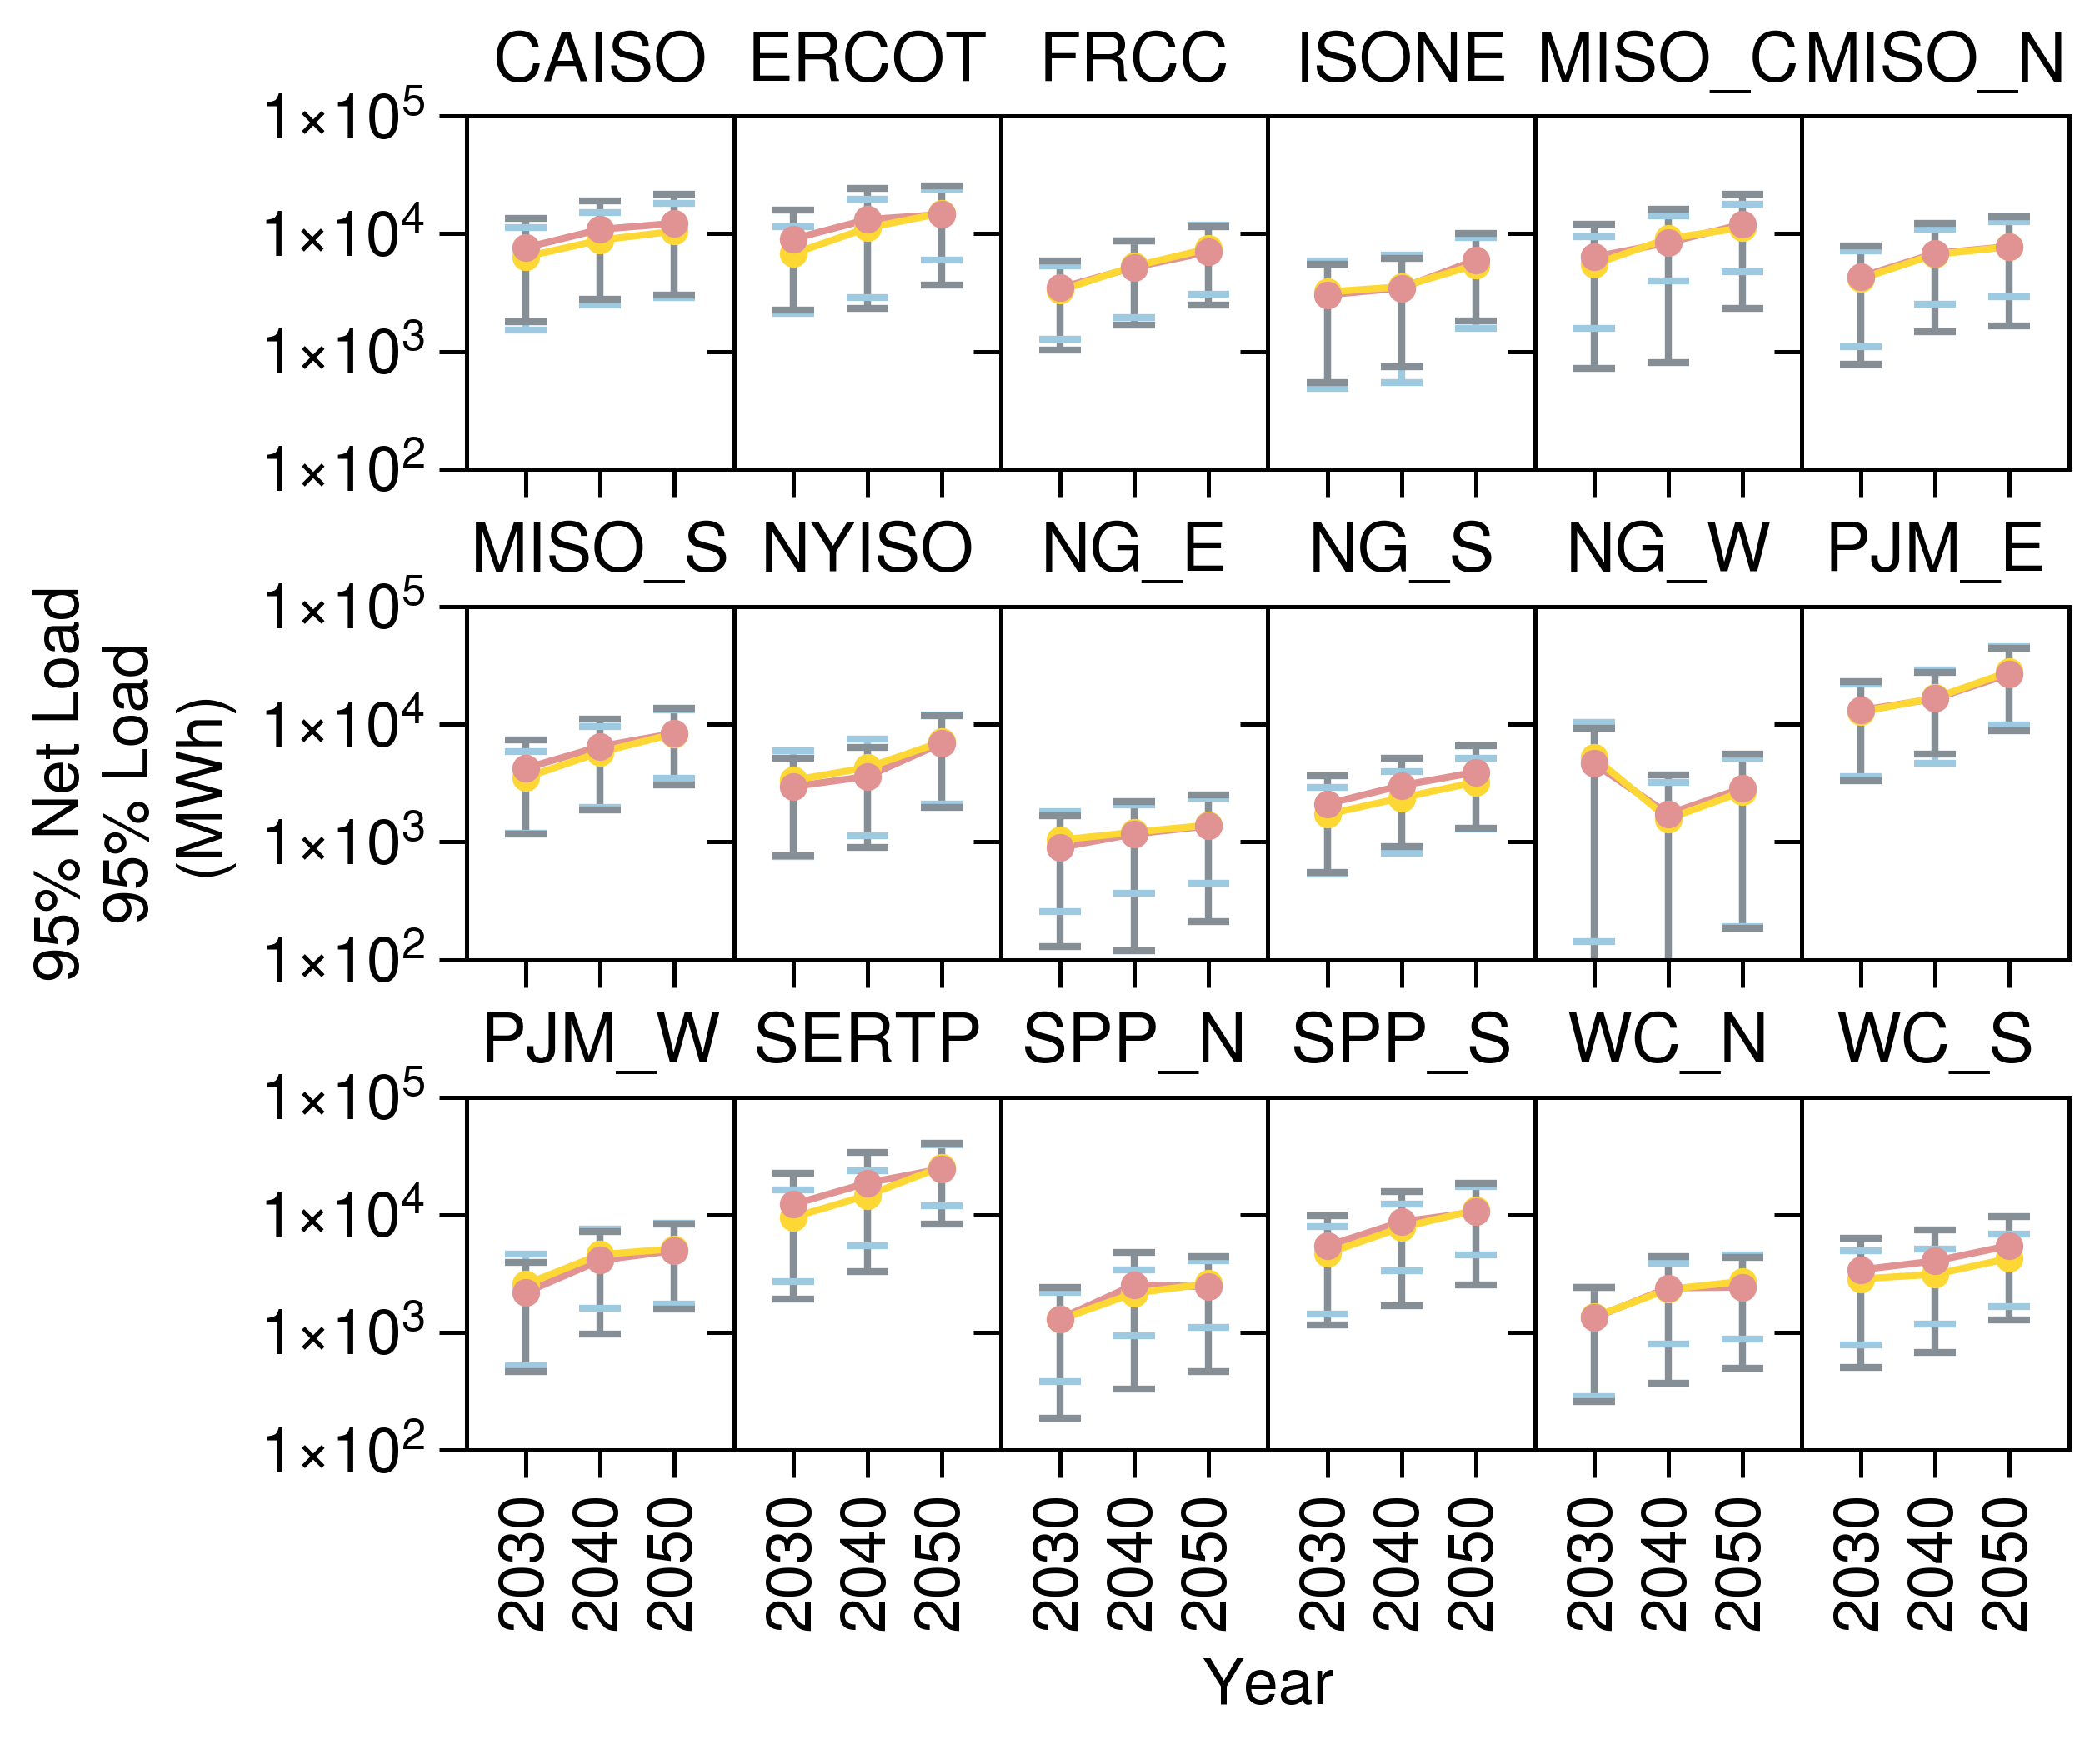

In [11]:
fig, axs = pplt.subplots(nrows=3, ncols=6, figsize=(4.2, 3.5),  wspace=0, hspace=2.2,sharey=True, sharex=True,spany=False,dpi=300)
fig.patch.set_facecolor('white')
data30_1 = data30.copy()
data40_1 = data40.copy()
data50_1 = data50.copy()
data30 = np.load('your_directory/loadvio_2030.npz', allow_pickle=True)['violin'].item()
data40 = np.load('your_directory/loadvio_2040.npz', allow_pickle=True)['violin'].item()
data50 = np.load('your_directory/loadvio_2050.npz', allow_pickle=True)['violin'].item()
data30 = normalize_by_rcp45cooler_min(data30,data30)
data40 = normalize_by_rcp45cooler_min(data40,data30)
data50 = normalize_by_rcp45cooler_min(data50,data30)
label_num = [str(i + 1) for i in range(18)]
k = 0
for i, sub_id in enumerate(label_num):
    ax = axs[k+i]
    data_rcp45 = {}
    data_rcp85 = {}
    for year, dataset, dataset1 in zip([2030, 2040, 2050], [data30, data40, data50], [data30_1, data40_1, data50_1]):
        sub_data = dataset.get(sub_id, {})
        sub_data1 = dataset1.get(sub_id, {})
        data_rcp45[year] = sub_data1['rcp85hotter']
        data_rcp85[year] = sub_data['rcp85hotter']
    if data_rcp45 and data_rcp85:
        df_rcp45 = pd.DataFrame(dict(sorted(data_rcp45.items())))
        df_rcp85 = pd.DataFrame(dict(sorted(data_rcp85.items())))
        xlabels = [str(year) for year in sorted(data_rcp45.keys())]
        x_pos_45 = np.arange(len(xlabels))
        x_pos_85 = x_pos_45 + 0.5
        lower_rcp45 = np.percentile(df_rcp45, 10, axis=0)
        upper_rcp45 = np.percentile(df_rcp45, 90, axis=0)
        mean_rcp45 = (lower_rcp45 + upper_rcp45) / 2
        err_low_rcp45 = mean_rcp45 - lower_rcp45
        err_high_rcp45 = upper_rcp45 - mean_rcp45
        lower_rcp85 = np.percentile(df_rcp85, 10, axis=0)
        upper_rcp85 = np.percentile(df_rcp85, 90, axis=0)
        mean_rcp85 = (lower_rcp85 + upper_rcp85) / 2
        err_low_rcp85 = mean_rcp85 - lower_rcp85
        err_high_rcp85 = upper_rcp85 - mean_rcp85
        for j in range(3):
            ax.errorbar(x_pos_45[j], mean_rcp85[j], yerr=np.array([[err_low_rcp85[j]], [err_high_rcp85[j]]]), elinewidth=1, capthick=1,
                        fmt='o', ms=4, markerfacecolor='#FDD835', markeredgecolor='none', ecolor='#9ECAE1', capsize=3, label='RCP8.5')
            ax.errorbar(x_pos_45[j], mean_rcp45[j], yerr=np.array([[err_low_rcp45[j]], [err_high_rcp45[j]]]), elinewidth=1, capthick=1,
                        fmt='o', ms=4, markerfacecolor=colors_rcp85[2], markeredgecolor='none', ecolor='gray6', capsize=3, label='RCP4.5')
        ax.plot(x_pos_45, mean_rcp45, '-', color=colors_rcp85[2], lw=1, label='RCP4.5 Trend')
        ax.plot(x_pos_45, mean_rcp85, '-', color='#FDD835', lw=1, label='RCP4.5 Trend')
        ax.tick_params(axis='y', labelsize=6)
        ax.set_title(label_list[i], fontsize=9)
        ax.format(xticklabels=['2030','2040','2050'],xrotation =90,xticks=[0, 1, 2], xlim=[-0.8,2.8],xtickminor=False, yformatter='sci',ylim=[100,100000],fontsize=9,yticks=[100,1000,10000,100000],yscale='log',grid=False)
axs[1,:].format(ylabel='95% Net Load\n95% Load\n(MWh)',xlabel='Year',xticklabelsize=9, yticklabelsize=9)